# Mental Health in Tech Survey: Exploratory Data Analysis

**Project type:** Exploratory Data Analysis  
**Contribution:** Individual  
**Dataset:** OSMI Mental Health in Tech Survey, 2014

This notebook explores treatment seeking, workplace attitudes, access to support, and how patterns vary across demographic and organizational groups. It also constructs a transparent **Workplace Mental Health Support Index** for descriptive comparison. The index is not a clinical score.

## Project summary

Mental health affects employee well-being, engagement, and the ability to work effectively, yet people may hesitate to seek help when workplace policies are unclear or disclosure feels unsafe. This project analyzes 1,259 responses from the 2014 Open Sourcing Mental Illness (OSMI) Mental Health in Tech Survey. The survey captures demographic context, treatment seeking, family history, work interference, employer-provided resources, perceived consequences, and willingness to discuss mental health.

The workflow begins with schema, missing-value, duplicate, and category checks. Implausible ages are treated as missing instead of being silently capped. Free-text gender responses are consolidated into Female, Male, and Other / self-described while retaining the original field. Missing state values are retained as not applicable or missing because the question applies mainly to US respondents. Optional comments are analyzed only at an aggregate level.

The analysis combines distributions, cross-tabulations, treatment-seeking rates, geographic comparisons, company-size comparisons, 100% stacked response charts, and bias-corrected Cramér’s V associations. A Workplace Mental Health Support Index is created from 11 policy and psychological-safety questions. Favorable answers receive 1, uncertain or partial answers generally receive 0.5, and unfavorable answers receive 0; ordered leave responses range from 0 to 1. The mean is scaled to 0–100.

The notebook is descriptive and exploratory. It does not diagnose mental illness, establish causality, or claim that the sample represents the entire technology workforce. Its purpose is to identify visible patterns, data-quality limitations, and practical questions that employers and analysts may investigate further.

## Problem statement

Explore how mental-health experiences and attitudes differ across geography, demographics, and workplace conditions, and identify the categorical factors most strongly associated with reported treatment seeking.

### Business objective

Help people teams and workplace leaders understand where employees report stronger or weaker support, which policies may need clearer communication, and where psychological-safety concerns appear in this historical survey sample.

## 1. Setup and data loading

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Self-contained helper functions for Google Colab
GENDER_MAP = {
    "female": "Female", "f": "Female", "woman": "Female", "female (cis)": "Female",
    "cis female": "Female", "cis-female/femme": "Female", "femake": "Female",
    "male": "Male", "m": "Male", "man": "Male", "male (cis)": "Male",
    "cis male": "Male", "mal": "Male", "male-ish": "Male", "maile": "Male",
    "make": "Male", "msle": "Male", "mail": "Male", "malr": "Male",
    "cis man": "Male", "m|": "Male",
}

SUPPORT_MAPS = {
    "benefits": {"Yes": 1, "Don't know": 0.5, "No": 0},
    "care_options": {"Yes": 1, "Not sure": 0.5, "No": 0},
    "wellness_program": {"Yes": 1, "Don't know": 0.5, "No": 0},
    "seek_help": {"Yes": 1, "Don't know": 0.5, "No": 0},
    "anonymity": {"Yes": 1, "Don't know": 0.5, "No": 0},
    "leave": {"Very easy": 1, "Somewhat easy": 0.75, "Don't know": 0.5,
              "Somewhat difficult": 0.25, "Very difficult": 0},
    "mental_health_consequence": {"No": 1, "Maybe": 0.5, "Yes": 0},
    "coworkers": {"Yes": 1, "Some of them": 0.5, "No": 0},
    "supervisor": {"Yes": 1, "Some of them": 0.5, "No": 0},
    "mental_vs_physical": {"Yes": 1, "Don't know": 0.5, "No": 0},
    "obs_consequence": {"No": 1, "Yes": 0},
}


def normalize_gender(value: object) -> str:
    """Consolidate free-text gender responses without inferring unknown identities."""
    if pd.isna(value):
        return "Other / self-described"
    raw = str(value).strip()
    key = raw.lower()
    if key in GENDER_MAP:
        return GENDER_MAP[key]
    if any(token in key for token in ("female", "woman", "femail")):
        return "Female"
    if any(token in key for token in ("male", "man", "guy")) and not any(
        token in key for token in ("female", "woman")
    ):
        return "Male"
    return "Other / self-described"


def load_data(path_or_buffer: str | Path | object) -> pd.DataFrame:
    """Load the survey CSV and validate the minimum expected schema."""
    df = pd.read_csv(path_or_buffer)
    required = {"Age", "Gender", "Country", "treatment", "family_history"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {', '.join(sorted(missing))}")
    return df


def clean_data(raw: pd.DataFrame) -> pd.DataFrame:
    """Return an analysis-ready copy while retaining the source columns."""
    df = raw.copy()
    df.columns = df.columns.str.strip()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    df.loc[~df["Age"].between(18, 75), "Age"] = np.nan
    df["Gender_clean"] = df["Gender"].map(normalize_gender)
    df["self_employed"] = df["self_employed"].fillna("Unknown")
    df["work_interfere"] = df["work_interfere"].fillna("Not reported")
    df["state"] = df["state"].fillna("Not applicable / missing")
    df["comments"] = df["comments"].fillna("")

    score_parts = pd.DataFrame(index=df.index)
    for column, mapping in SUPPORT_MAPS.items():
        score_parts[column] = df[column].map(mapping)
    df["support_index"] = (score_parts.mean(axis=1) * 100).round(1)
    df["support_band"] = pd.cut(
        df["support_index"], bins=[-0.1, 39.9, 69.9, 100],
        labels=["Low", "Moderate", "High"]
    )
    df["age_group"] = pd.cut(
        df["Age"], bins=[17, 24, 34, 44, 54, 75],
        labels=["18–24", "25–34", "35–44", "45–54", "55–75"]
    )
    return df


def pct(series: pd.Series, value: object = "Yes") -> float:
    """Percentage of non-null values equal to the chosen response."""
    valid = series.dropna()
    return float(valid.eq(value).mean() * 100) if len(valid) else 0.0


def treatment_rate_table(df: pd.DataFrame, column: str, min_count: int = 10) -> pd.DataFrame:
    """Treatment-seeking rate and sample size by a categorical dimension."""
    out = (
        df.dropna(subset=[column, "treatment"])
        .groupby(column, observed=True)["treatment"]
        .agg(responses="size", treatment_rate=lambda s: s.eq("Yes").mean() * 100)
        .reset_index()
    )
    return out.loc[out["responses"] >= min_count].sort_values("treatment_rate", ascending=False)


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramér's V for two categorical variables."""
    from scipy.stats import chi2_contingency
    table = pd.crosstab(x, y)
    if min(table.shape) < 2 or table.to_numpy().sum() == 0:
        return 0.0
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denom = min(kcorr - 1, rcorr - 1)
    return float(np.sqrt(phi2corr / denom)) if denom > 0 else 0.0



sns.set_theme(style='whitegrid', context='notebook')
PURPLE, TEAL, ORANGE, GREY = '#7C3AED', '#0F766E', '#F59E0B', '#94A3B8'
plt.rcParams.update({'figure.figsize': (10, 5.5), 'axes.titleweight': 'bold', 'axes.titlesize': 14})

DATA_PATH = Path('data/survey.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('survey.csv')
raw = load_data(DATA_PATH)
df = clean_data(raw)
print(f'Loaded {len(raw):,} rows and {raw.shape[1]} source columns.')

Loaded 1,259 rows and 27 source columns.


## 2. Know the data

In [2]:
display(raw.head())

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
schema = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'non_null': raw.notna().sum(),
                       'missing': raw.isna().sum(), 'unique': raw.nunique(dropna=True)})
display(schema)

,dtype,non_null,missing,unique
Timestamp,object,1259,0,1246
Age,int64,1259,0,53
Gender,object,1259,0,49
Country,object,1259,0,48
state,object,744,515,45
self_employed,object,1241,18,2
family_history,object,1259,0,2
treatment,object,1259,0,2
work_interfere,object,995,264,4
no_employees,object,1259,0,6


In [4]:
quality = pd.Series({
    'Rows': len(raw), 'Columns': raw.shape[1], 'Exact duplicate rows': raw.duplicated().sum(),
    'Missing cells': int(raw.isna().sum().sum()),
    'Invalid ages outside 18–75': int((~raw['Age'].between(18, 75)).sum())
}, name='Value').to_frame()
display(quality)

,Value
Rows,1259
Columns,27
Exact duplicate rows,0
Missing cells,1892
Invalid ages outside 18–75,8


### Missing values

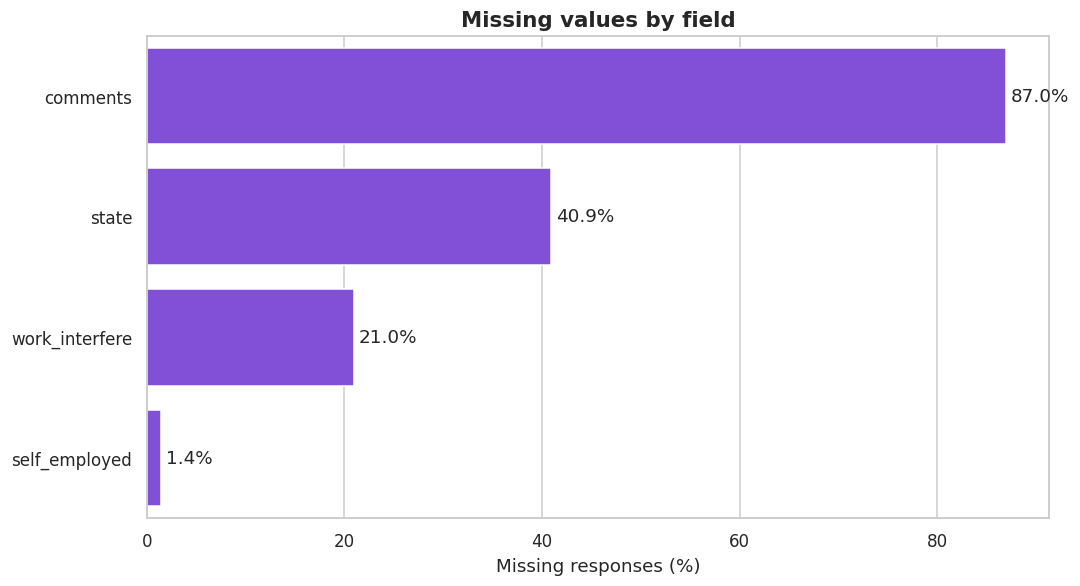

In [5]:
missing = raw.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = missing.div(len(raw)).mul(100)
fig, ax = plt.subplots()
sns.barplot(x=missing_pct.values, y=missing_pct.index, color=PURPLE, ax=ax)
ax.set(title='Missing values by field', xlabel='Missing responses (%)', ylabel='')
for i, v in enumerate(missing_pct.values): ax.text(v + .5, i, f'{v:.1f}%', va='center')
plt.tight_layout(); plt.show()

**Interpretation:** `comments` is intentionally optional, `state` is mostly relevant to US respondents, and `work_interfere` contains substantial non-response. Missingness should not automatically be treated as a negative answer.

### Age validation and cleaning

In [6]:
display(raw.loc[~raw['Age'].between(18, 75), ['Age', 'Gender', 'Country']])
print(f'Valid cleaned ages: {df.Age.notna().sum():,}; median age: {df.Age.median():.0f}.')

Valid cleaned ages: 1,251; median age: 31.


,Age,Gender,Country
143,-29,Male,United States
364,329,Male,United States
390,99999999999,All,Zimbabwe
715,-1726,male,United Kingdom
734,5,Male,United States
989,8,A little about you,"Bahamas, The"
1090,11,male,United States
1127,-1,p,United States


### Original gender labels and consolidated groups

In [7]:
gender_audit = (df.groupby(['Gender_clean', 'Gender']).size().rename('responses')
                  .reset_index().sort_values(['Gender_clean', 'responses'], ascending=[True, False]))
display(gender_audit.head(30))

,Gender_clean,Gender,responses
3,Female,Female,121
13,Female,female,62
1,Female,F,38
11,Female,f,15
9,Female,Woman,3
4,Female,Female,2
6,Female,Female (trans),2
0,Female,Cis Female,1
2,Female,Femake,1
5,Female,Female (cis),1


## 3. Univariate analysis

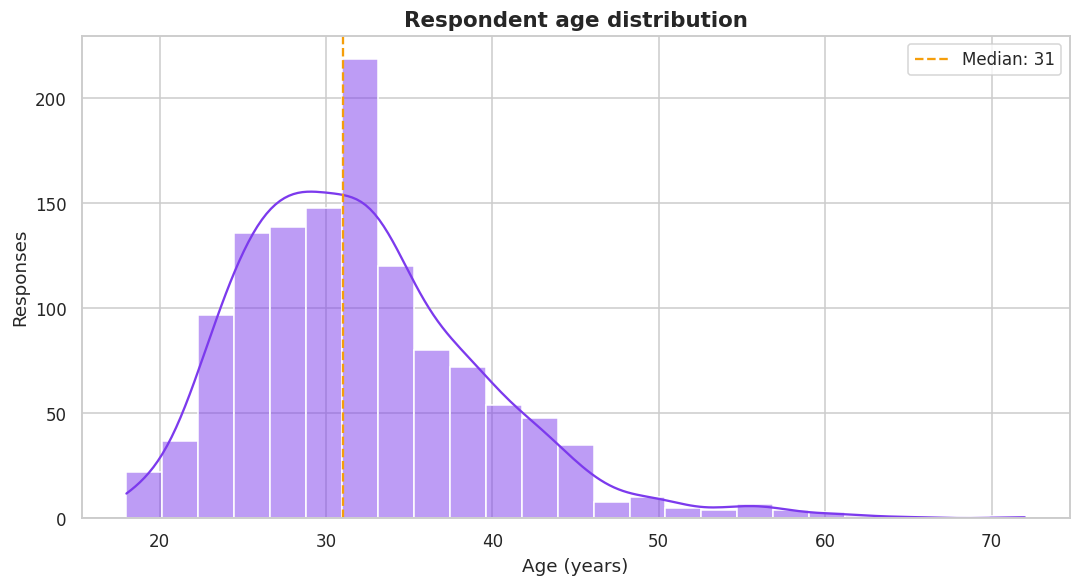

In [8]:
fig, ax = plt.subplots()
sns.histplot(data=df, x='Age', bins=25, kde=True, color=PURPLE, ax=ax)
ax.axvline(df.Age.median(), color=ORANGE, ls='--', label=f'Median: {df.Age.median():.0f}')
ax.set(title='Respondent age distribution', xlabel='Age (years)', ylabel='Responses'); ax.legend()
plt.tight_layout(); plt.show()

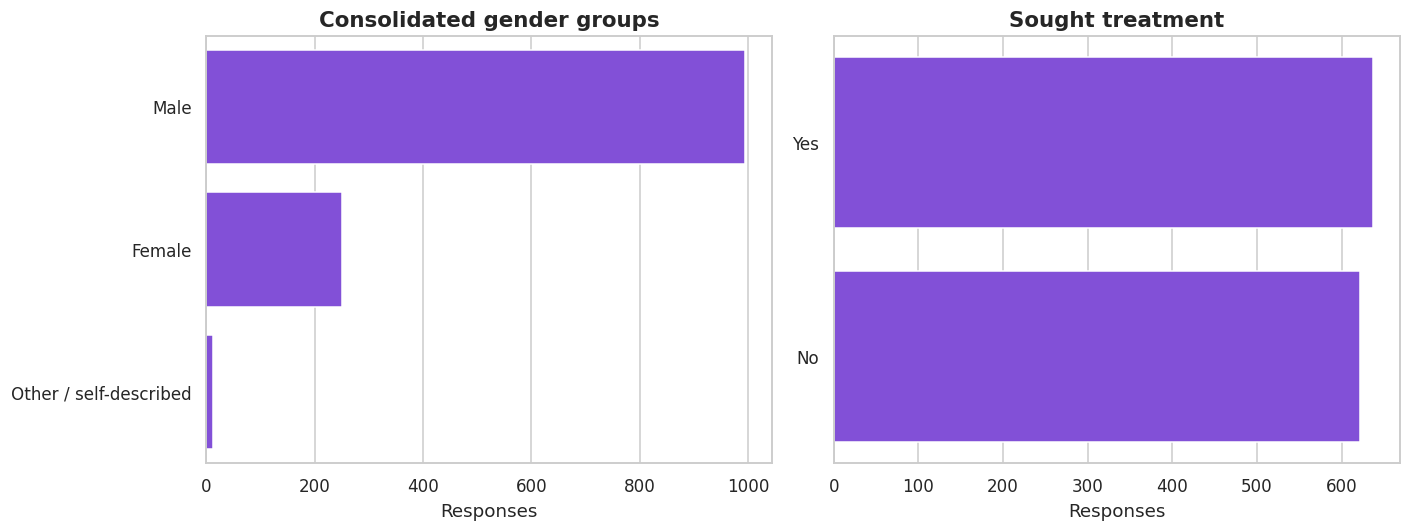

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes, ['Gender_clean', 'treatment'], ['Consolidated gender groups', 'Sought treatment']):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, color=PURPLE, ax=ax)
    ax.set(title=title, xlabel='Responses', ylabel='')
plt.tight_layout(); plt.show()

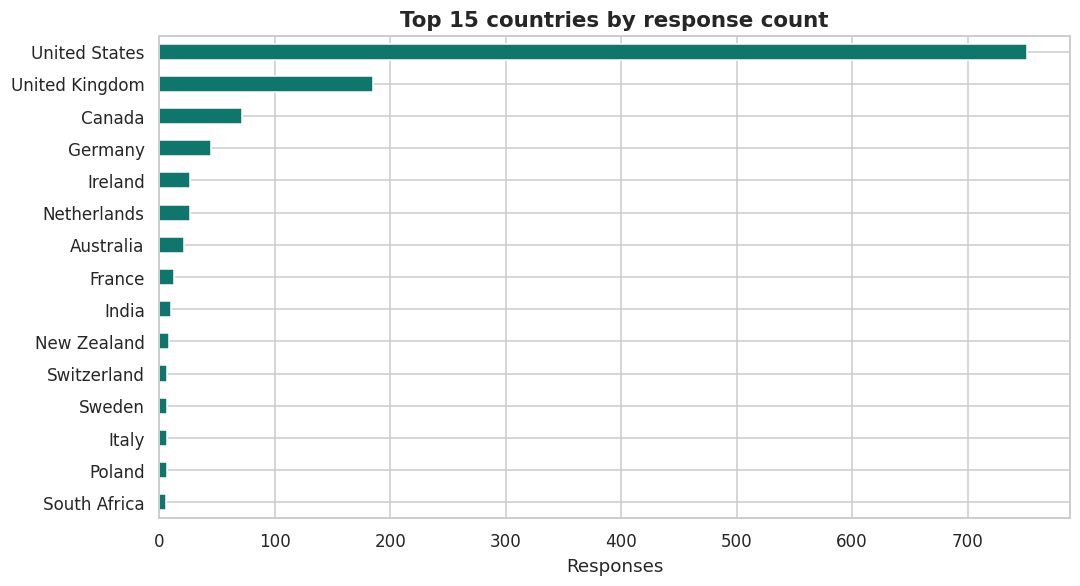

In [10]:
country_counts = df['Country'].value_counts().head(15).sort_values()
country_counts.plot.barh(color=TEAL, title='Top 15 countries by response count')
plt.xlabel('Responses'); plt.ylabel(''); plt.tight_layout(); plt.show()

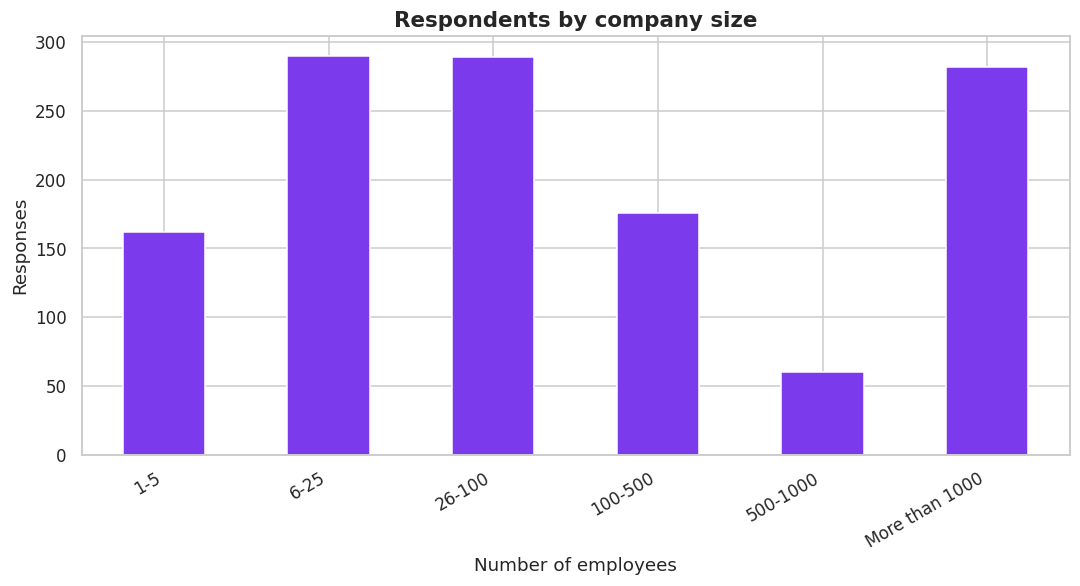

In [11]:
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
counts = df['no_employees'].value_counts().reindex(order)
counts.plot.bar(color=PURPLE, title='Respondents by company size')
plt.xlabel('Number of employees'); plt.ylabel('Responses'); plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

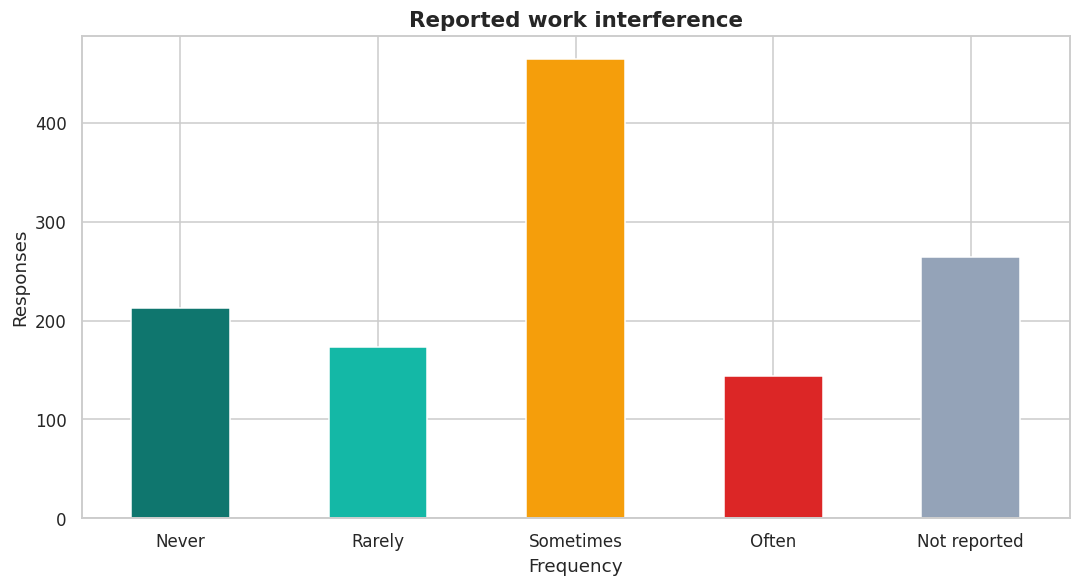

In [12]:
wi_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not reported']
counts = df['work_interfere'].value_counts().reindex(wi_order).dropna()
counts.plot.bar(color=[TEAL, '#14B8A6', ORANGE, '#DC2626', GREY], title='Reported work interference')
plt.xlabel('Frequency'); plt.ylabel('Responses'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 4. Bivariate analysis: treatment seeking

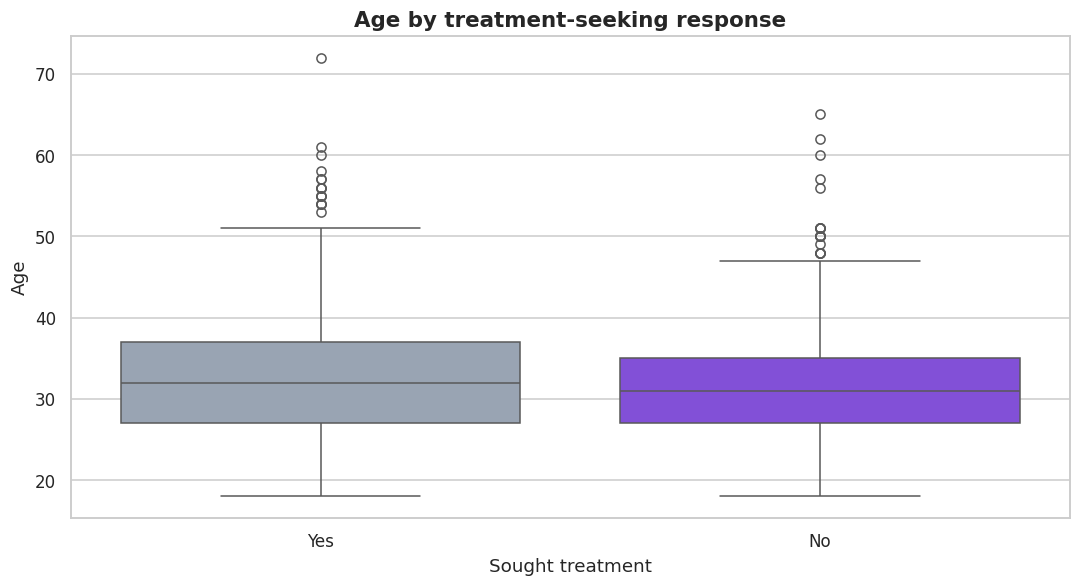

In [13]:
age_treatment = df.dropna(subset=['Age'])
fig, ax = plt.subplots()
sns.boxplot(data=age_treatment, x='treatment', y='Age', palette=[GREY, PURPLE], ax=ax)
ax.set(title='Age by treatment-seeking response', xlabel='Sought treatment', ylabel='Age')
plt.tight_layout(); plt.show()

treatment,No,Yes
family_history,,
No,64.5,35.5
Yes,25.8,74.2


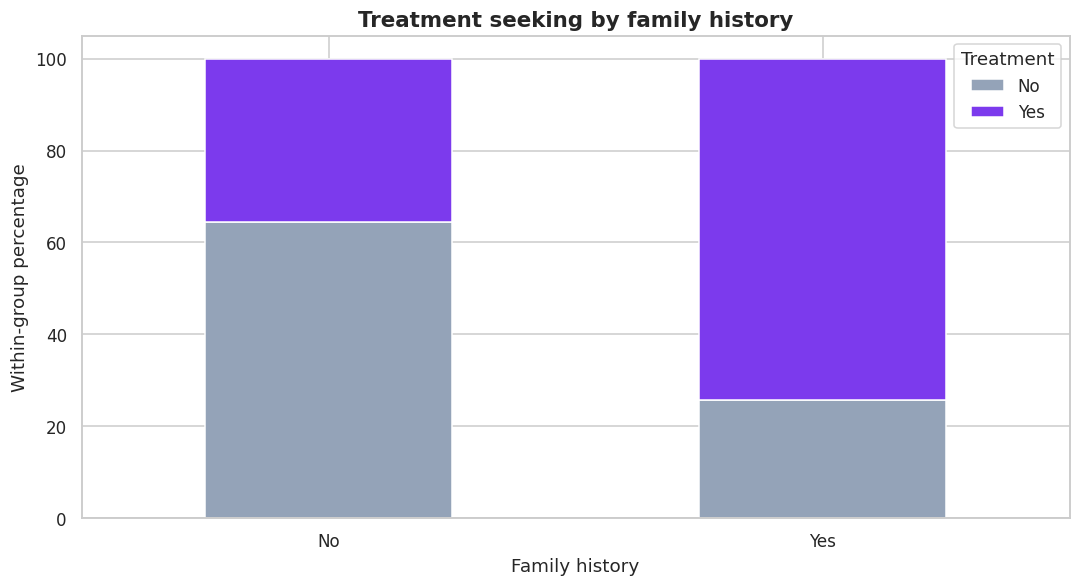

In [14]:
ct = pd.crosstab(df['family_history'], df['treatment'], normalize='index').mul(100)
ct.plot.bar(stacked=True, color=[GREY, PURPLE], title='Treatment seeking by family history')
plt.ylabel('Within-group percentage'); plt.xlabel('Family history'); plt.xticks(rotation=0)
plt.legend(title='Treatment'); plt.tight_layout(); plt.show()
display(ct.round(1))

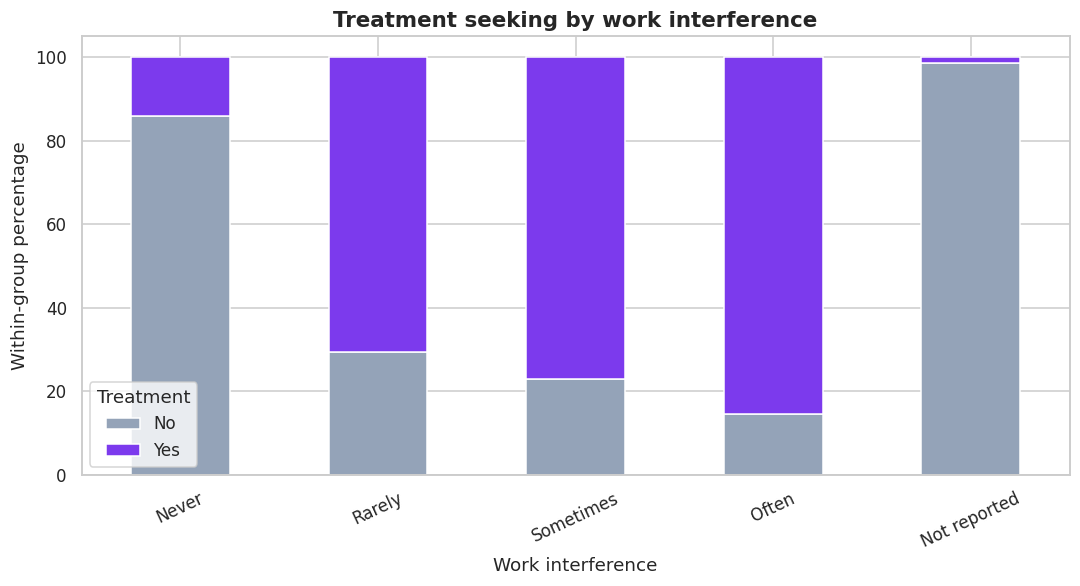

In [15]:
ct = pd.crosstab(df['work_interfere'], df['treatment'], normalize='index').mul(100).reindex(wi_order)
ct.plot.bar(stacked=True, color=[GREY, PURPLE], title='Treatment seeking by work interference')
plt.ylabel('Within-group percentage'); plt.xlabel('Work interference'); plt.xticks(rotation=25)
plt.legend(title='Treatment'); plt.tight_layout(); plt.show()

,Gender_clean,responses,treatment_rate
2,Other / self-described,13,92.3
0,Female,251,68.9
1,Male,995,45.4


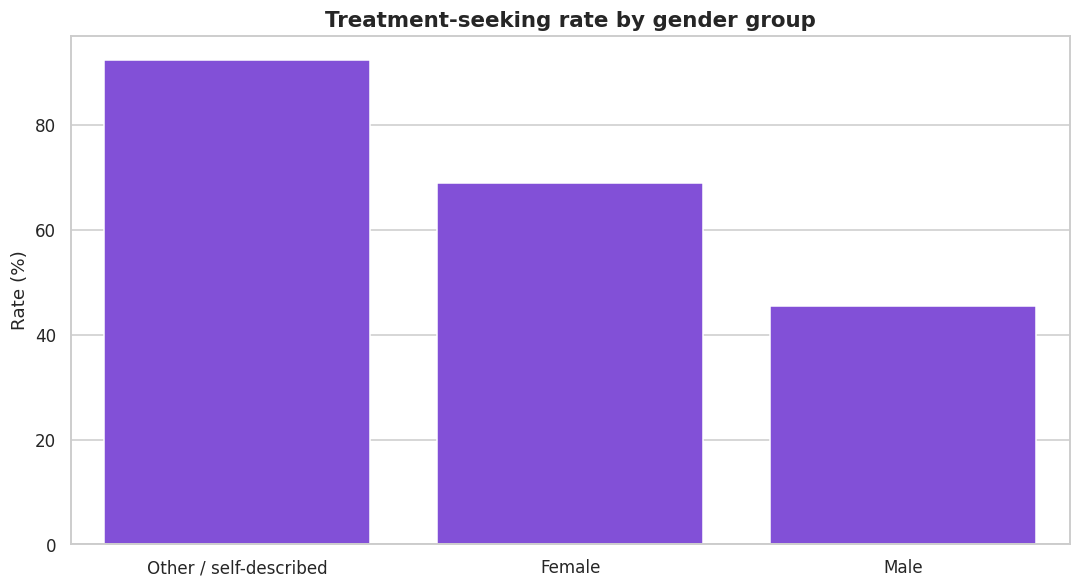

In [16]:
gender_rates = treatment_rate_table(df, 'Gender_clean', min_count=1)
sns.barplot(data=gender_rates, x='Gender_clean', y='treatment_rate', color=PURPLE)
plt.title('Treatment-seeking rate by gender group'); plt.xlabel(''); plt.ylabel('Rate (%)')
plt.tight_layout(); plt.show(); display(gender_rates.round(1))

,Country,responses,treatment_rate
0,Australia,21,61.9
45,United States,751,54.6
7,Canada,72,51.4
44,United Kingdom,185,50.3
21,Ireland,27,48.1
17,Germany,45,46.7
28,Netherlands,27,33.3
20,India,10,30.0
15,France,13,15.4


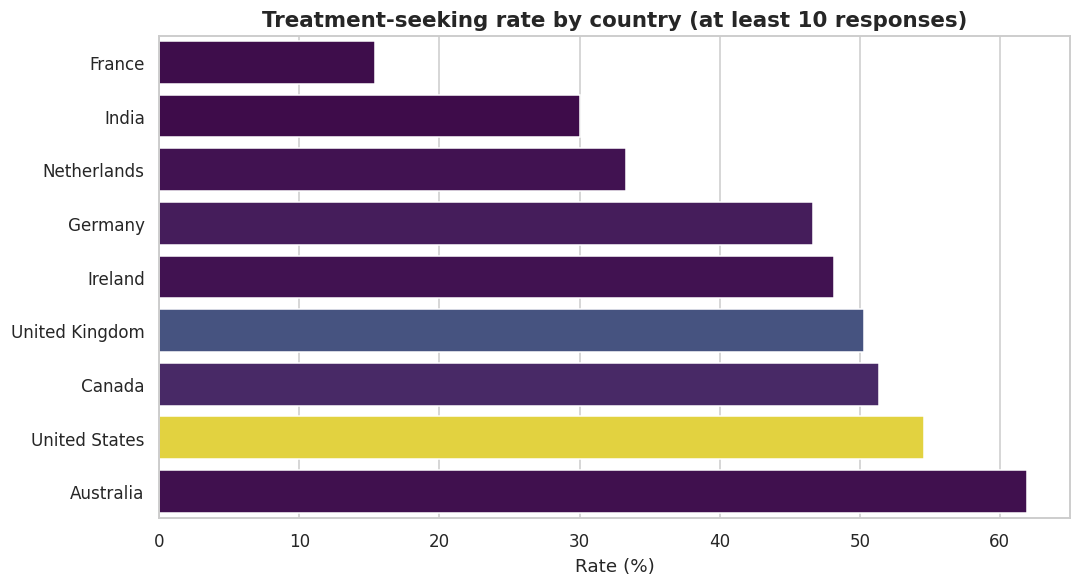

In [17]:
country_rates = treatment_rate_table(df, 'Country', min_count=10).head(15).sort_values('treatment_rate')
sns.barplot(data=country_rates, x='treatment_rate', y='Country', hue='responses', palette='viridis', legend=False)
plt.title('Treatment-seeking rate by country (at least 10 responses)'); plt.xlabel('Rate (%)'); plt.ylabel('')
plt.tight_layout(); plt.show(); display(country_rates.sort_values('treatment_rate', ascending=False).round(1))

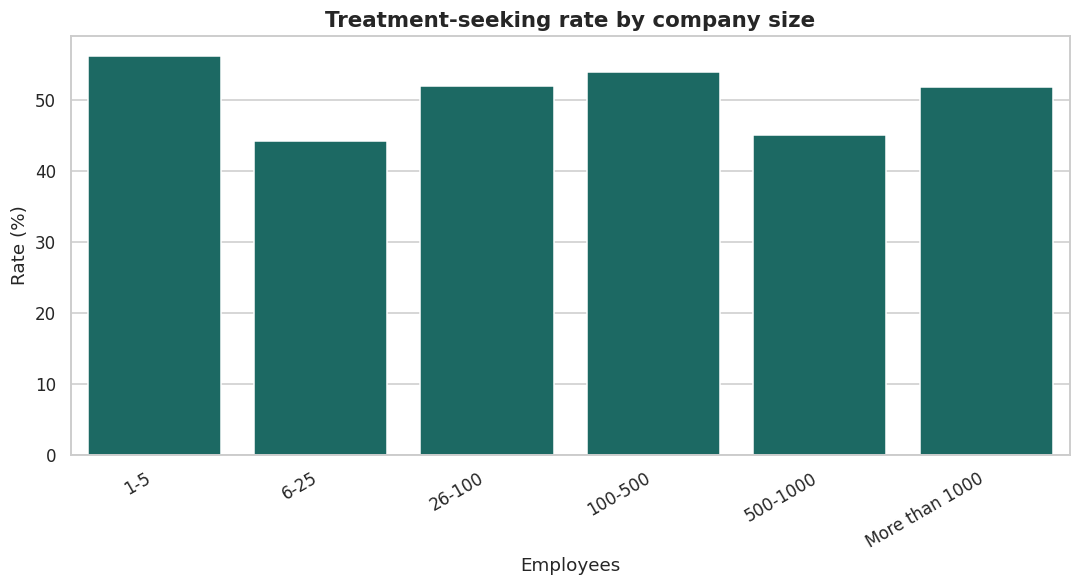

In [18]:
company_rates = treatment_rate_table(df, 'no_employees', min_count=1)
company_rates['no_employees'] = pd.Categorical(company_rates['no_employees'], order, ordered=True)
company_rates = company_rates.sort_values('no_employees')
sns.barplot(data=company_rates, x='no_employees', y='treatment_rate', color=TEAL)
plt.title('Treatment-seeking rate by company size'); plt.xlabel('Employees'); plt.ylabel('Rate (%)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## 5. Workplace support and psychological safety

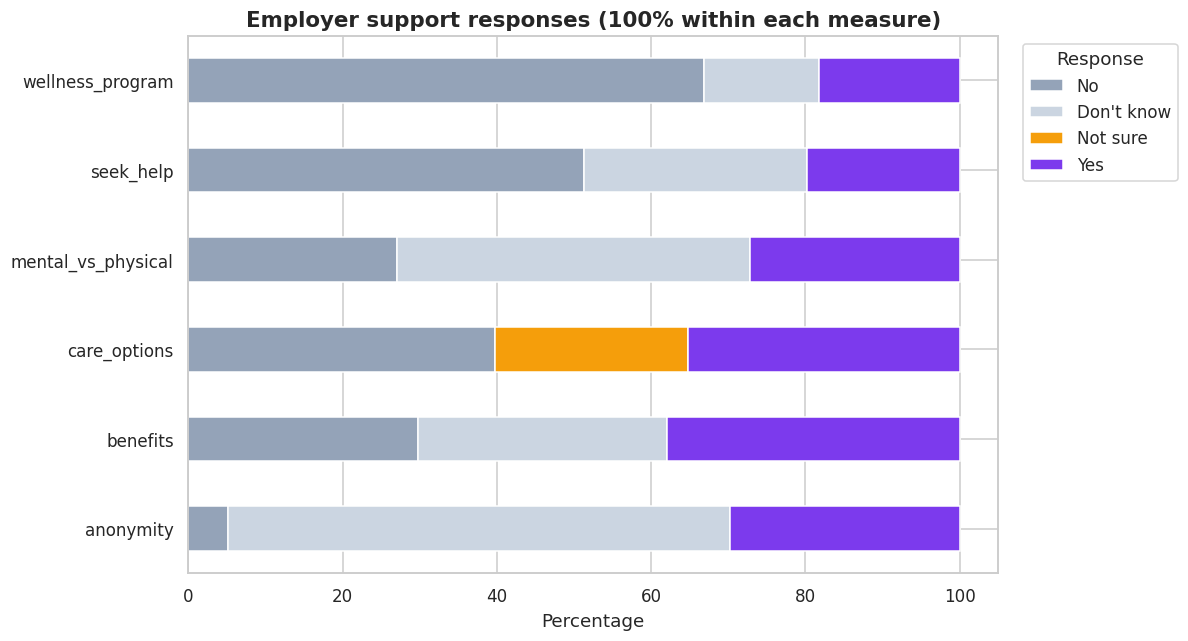

In [19]:
support_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'mental_vs_physical']
long = df[support_cols].melt(var_name='measure', value_name='response')
shares = pd.crosstab(long['measure'], long['response'], normalize='index').mul(100)
preferred = [c for c in ['No', "Don't know", 'Not sure', 'Yes'] if c in shares.columns]
shares[preferred].plot.barh(stacked=True, color=[GREY, '#CBD5E1', ORANGE, PURPLE][:len(preferred)], figsize=(11, 6))
plt.title('Employer support responses (100% within each measure)'); plt.xlabel('Percentage'); plt.ylabel('')
plt.legend(title='Response', bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

,count,mean,median
treatment,,,
No,622,51.8,52.3
Yes,637,53.3,52.3


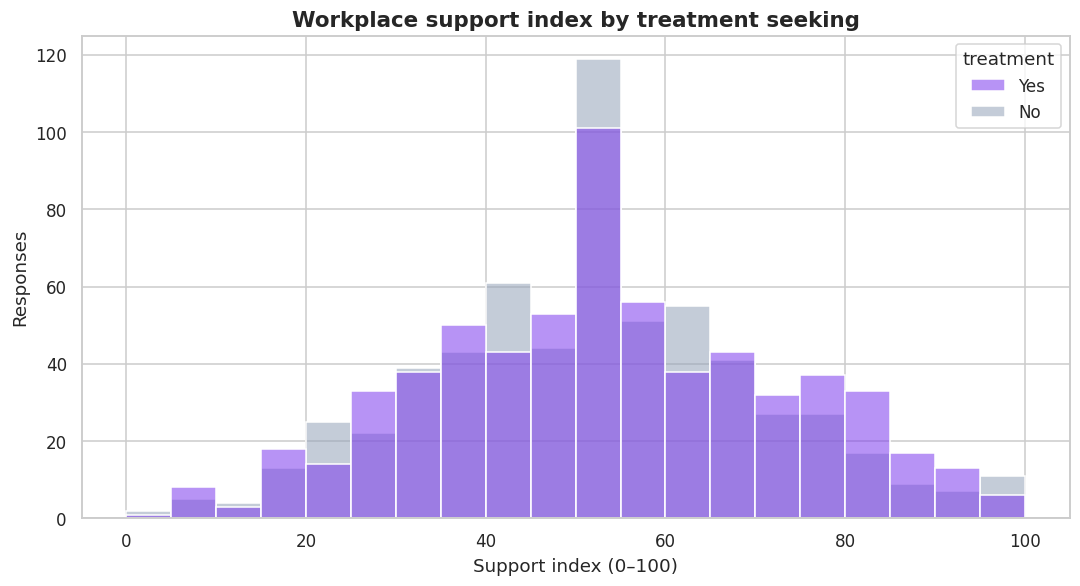

In [20]:
fig, ax = plt.subplots()
sns.histplot(data=df, x='support_index', hue='treatment', bins=20, multiple='layer',
             palette={'Yes': PURPLE, 'No': GREY}, alpha=.55, ax=ax)
ax.set(title='Workplace support index by treatment seeking', xlabel='Support index (0–100)', ylabel='Responses')
plt.tight_layout(); plt.show()
display(df.groupby('treatment')['support_index'].agg(['count', 'mean', 'median']).round(1))

,no_employees,mean,count
0,1-5,49.4,162
1,6-25,49.1,290
2,26-100,51.1,289
3,100-500,53.2,176
4,500-1000,56.4,60
5,More than 1000,58.1,282


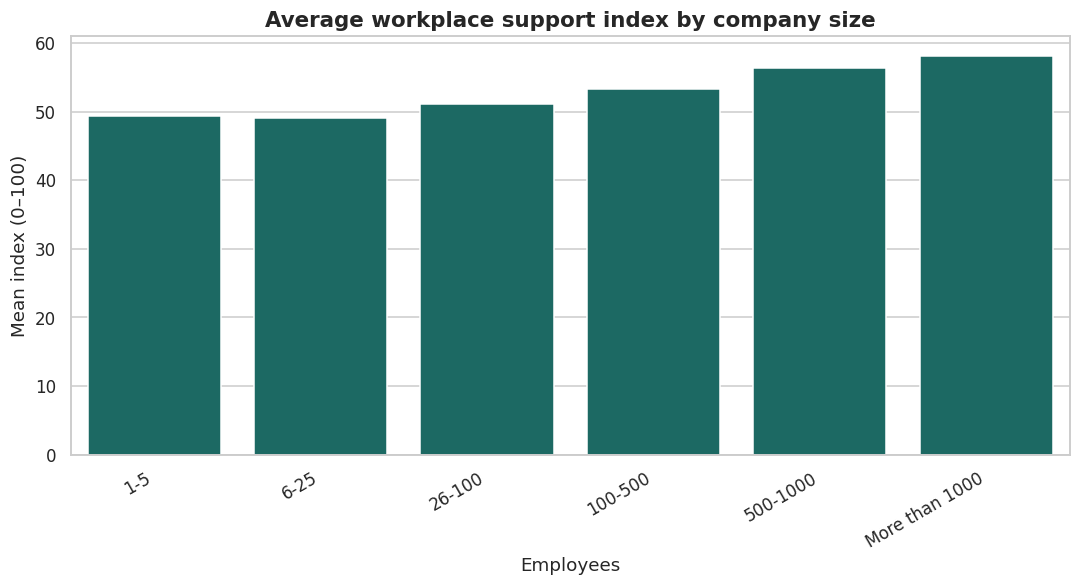

In [21]:
support_company = df.groupby('no_employees', observed=True)['support_index'].agg(['mean', 'count']).reindex(order).reset_index()
sns.barplot(data=support_company, x='no_employees', y='mean', color=TEAL)
plt.title('Average workplace support index by company size'); plt.xlabel('Employees'); plt.ylabel('Mean index (0–100)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show(); display(support_company.round(1))

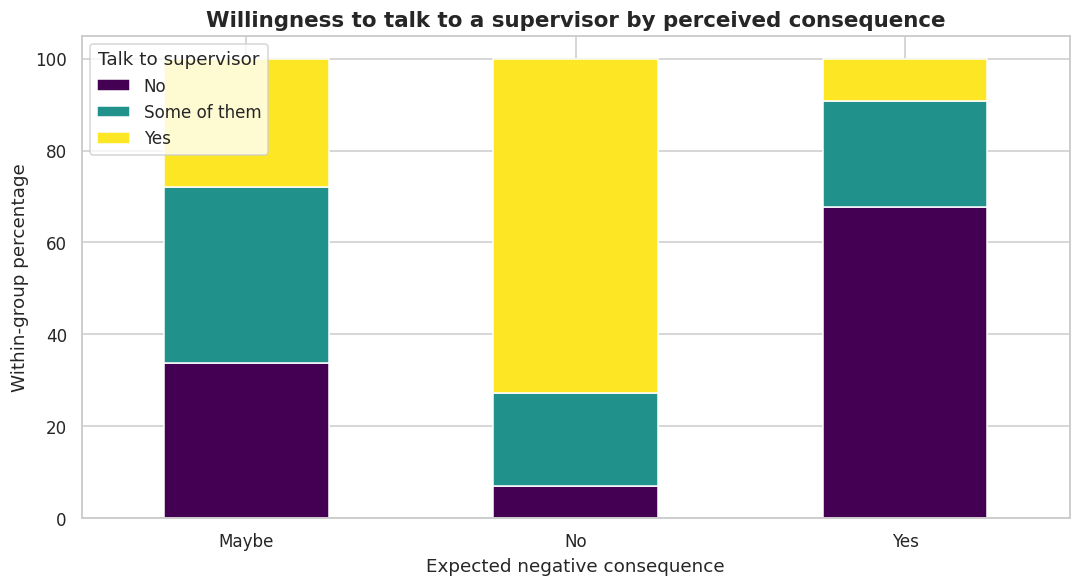

In [22]:
ct = pd.crosstab(df['mental_health_consequence'], df['supervisor'], normalize='index').mul(100)
ct.plot.bar(stacked=True, colormap='viridis', title='Willingness to talk to a supervisor by perceived consequence')
plt.ylabel('Within-group percentage'); plt.xlabel('Expected negative consequence'); plt.xticks(rotation=0)
plt.legend(title='Talk to supervisor'); plt.tight_layout(); plt.show()

## 6. Association analysis

,variable,cramers_v
1,work_interfere,0.685
0,family_history,0.377
3,care_options,0.272
2,benefits,0.223
14,Gender_clean,0.202
7,leave,0.144
6,anonymity,0.139
8,mental_health_consequence,0.127
4,wellness_program,0.087
5,seek_help,0.084


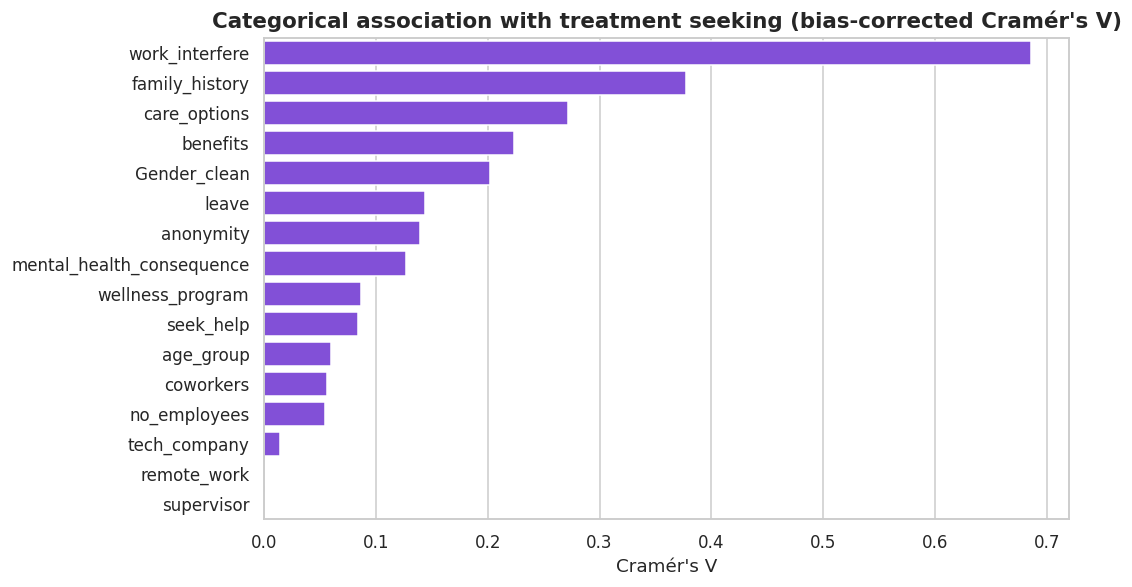

In [23]:
variables = ['family_history', 'work_interfere', 'benefits', 'care_options', 'wellness_program',
             'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'coworkers',
             'supervisor', 'remote_work', 'tech_company', 'no_employees', 'Gender_clean', 'age_group']
assoc = pd.DataFrame({'variable': variables,
                      'cramers_v': [cramers_v(df[v], df['treatment']) for v in variables]})
assoc = assoc.sort_values('cramers_v', ascending=False)
sns.barplot(data=assoc, x='cramers_v', y='variable', color=PURPLE)
plt.title("Categorical association with treatment seeking (bias-corrected Cramér's V)")
plt.xlabel("Cramér's V"); plt.ylabel(''); plt.tight_layout(); plt.show(); display(assoc.round(3))

**Interpretation:** Cramér’s V measures association strength, not direction or causation. Larger values identify variables whose response patterns differ more across treatment groups.

## 7. Optional comment analysis

,value
Comments supplied,163.0
Comment response rate (%),12.9
Median words per comment,29.0


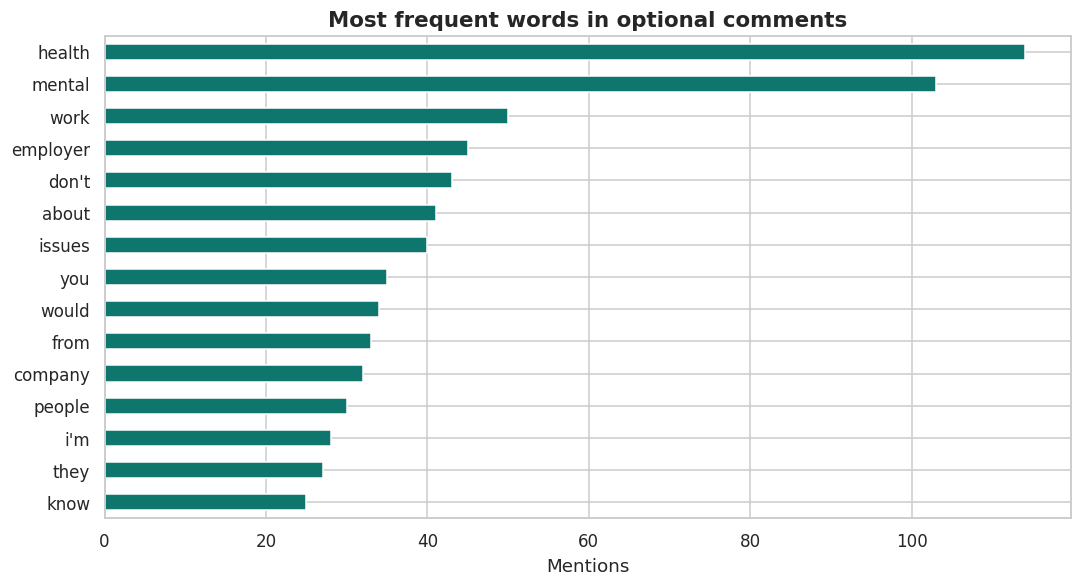

In [24]:
comments = df.loc[df['comments'].str.strip().ne(''), 'comments']
comment_stats = pd.Series({'Comments supplied': len(comments),
                           'Comment response rate (%)': len(comments) / len(df) * 100,
                           'Median words per comment': comments.str.split().str.len().median()})
display(comment_stats.round(1).to_frame('value'))

from collections import Counter
import re
stop = {'the','and','to','a','of','i','is','in','that','it','for','my','this','have','are','with','on','be','was','but','not','as','at','or','we'}
tokens = Counter(w for text in comments.str.lower() for w in re.findall(r"[a-z']{3,}", text) if w not in stop)
top_words = pd.DataFrame(tokens.most_common(15), columns=['word','count']).sort_values('count')
top_words.plot.barh(x='word', y='count', legend=False, color=TEAL, title='Most frequent words in optional comments')
plt.xlabel('Mentions'); plt.ylabel(''); plt.tight_layout(); plt.show()

**Privacy note:** Free-text comments may contain sensitive information. This notebook shows only aggregate word counts and does not reproduce individual comments.

## 8. Key findings generated from the data

In [25]:
top_assoc = assoc.iloc[0]
family = treatment_rate_table(df, 'family_history', min_count=1).set_index('family_history')['treatment_rate']
summary = pd.Series({
    'Treatment-seeking rate (%)': pct(df['treatment']),
    'Family-history rate (%)': pct(df['family_history']),
    'Average support index': df['support_index'].mean(),
    'Median valid age': df['Age'].median(),
    'Strongest observed treatment association': f"{top_assoc['variable']} (V={top_assoc['cramers_v']:.3f})",
    'Treatment rate with family history (%)': family.get('Yes', np.nan),
    'Treatment rate without family history (%)': family.get('No', np.nan),
})
display(summary.to_frame('result'))

,result
Treatment-seeking rate (%),50.595711
Family-history rate (%),39.078634
Average support index,52.545592
Median valid age,31.0
Strongest observed treatment association,work_interfere (V=0.685)
Treatment rate with family history (%),74.186992
Treatment rate without family history (%),35.462842


## Conclusions and recommendations

1. **Separate need from access.** Treatment seeking is a behavior influenced by need, awareness, affordability, availability, and stigma. It should not be interpreted as a direct prevalence estimate.
2. **Make support visible.** Benefits and programs are less useful when employees do not know they exist. Track “don’t know” responses as a communication gap.
3. **Strengthen psychological safety.** Compare perceived disclosure consequences with willingness to speak to supervisors and coworkers. Manager training and confidential channels may reduce fear.
4. **Review leave clarity.** Uncertainty about mental-health leave can itself be a barrier. Employers should publish clear, accessible policies.
5. **Use segmented results carefully.** Country and identity comparisons with small sample sizes are unstable. Minimum-count rules and sample sizes should always accompany percentages.

### Limitations

- The sample is non-random, self-selected, and heavily concentrated in a few countries.
- The survey is from 2014 and may not describe present-day workplaces.
- Responses are self-reported and cross-sectional, so the analysis cannot establish causality.
- Consolidating free-text gender labels improves chart readability but loses some identity detail; original responses remain available.
- The Workplace Mental Health Support Index is an analyst-defined descriptive measure, not a validated clinical instrument.
- Missing `work_interfere` values may be structurally related to not having a condition, but the dataset does not make that mechanism fully explicit.

### Next steps

Validate findings with newer survey waves, add statistical uncertainty for subgroup rates, test robustness of index weights, and collect representative longitudinal data before making policy-impact claims.

## 9. Export cleaned data

In [26]:
OUTPUT_PATH = Path('data/mental_health_tech_cleaned.csv')
OUTPUT_PATH.parent.mkdir(exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(df):,} cleaned rows to {OUTPUT_PATH}.')

Saved 1,259 cleaned rows to data/mental_health_tech_cleaned.csv.
